In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

Nous utilisérons le dataset `load_breast_cancer`

- Importez le dataset
- Définissez les ensembles d'apprentissage (75%) et test (25%) en mettant `random_state=44`
- Chaque donnée a combien d'attributs ?
- Il y a combien de données dans l'ensemble d'apprentissage (test) ?

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=44)

print("Nombre d'attributs par donnée :", X.shape[1])           # 30 attributs
print("Taille ensemble d'apprentissage :", X_train.shape[0])   # 426
print("Taille ensemble de test :", X_test.shape[0])            # 143

Nombre d'attributs par donnée : 30
Taille ensemble d'apprentissage : 426
Taille ensemble de test : 143


Nous utilisérons une autre méthode d'apprentissage supervisé (SVM)

```python
from sklearn.svm import SVC
```
https://scikit-learn.org/stable/modules/svm.html

- Faites l'apprentissage. Quel est le score (accuracy) sur l'ensemble de test ?

In [4]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm = SVC(random_state=42)
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)
score = accuracy_score(y_test, y_pred)
print(f"Score SVM (données brutes) : {score:.4f}")

Score SVM (données brutes) : 0.9580


Faites le prétraitement des données par `StandardScaler`

```python
from sklearn.preprocessing import StandardScaler
```

- Mettez les données prétraitées dans `X_train_s`, `X_test_s`
- Affichez la valeur moyenne et la déviation standard des données prétraitées
- Faites l'apprentissage sur les données prétraitées. Quel est le score ?

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)  # fit sur train, transform
X_test_s = scaler.transform(X_test)        # transform seulement sur test

print("Moyenne des données prétraitées (train) :", np.mean(X_train_s, axis=0).round(4))
print("Écart-type des données prétraitées (train) :", np.std(X_train_s, axis=0).round(4))
# Après StandardScaler : moyenne ≈ 0, std ≈ 1

svm_s = SVC(random_state=42)
svm_s.fit(X_train_s, y_train)
score_s = accuracy_score(y_test, svm_s.predict(X_test_s))
print(f"\nScore SVM (données standardisées) : {score_s:.4f}")

Moyenne des données prétraitées (train) : [-0. -0. -0. -0. -0. -0.  0.  0. -0.  0.  0.  0.  0. -0.  0. -0. -0.  0.
  0.  0.  0.  0. -0. -0.  0.  0. -0.  0. -0. -0.]
Écart-type des données prétraitées (train) : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]

Score SVM (données standardisées) : 0.9860


**Réduction de dimension**

Pour visualiser et pour accélérer le ML.

https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html

- Diminuez le nombre d'attributs à 2 (en utilisant les données normalisées)
- Dessinez ce dataset : axe x = Feature 0, axe y = Feature 1, les points colorés selon y (0 ou 1)

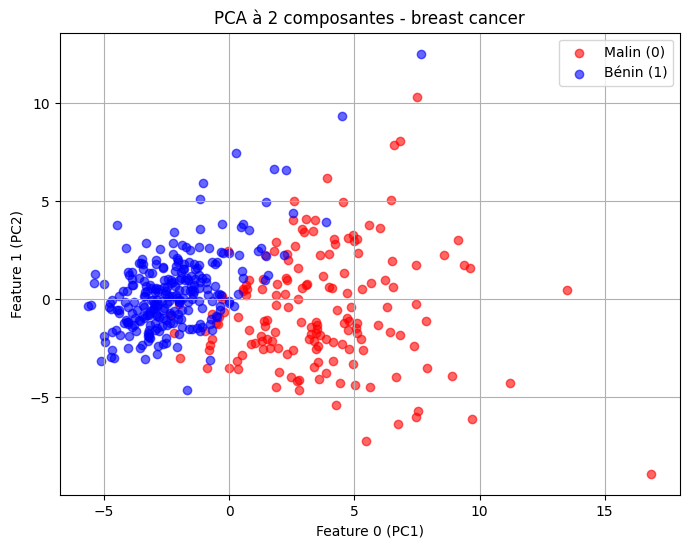

In [6]:
from sklearn.decomposition import PCA

pca2 = PCA(n_components=2)
X_train_pca2 = pca2.fit_transform(X_train_s)
X_test_pca2 = pca2.transform(X_test_s)

plt.figure(figsize=(8, 6))
plt.scatter(X_train_pca2[y_train == 0, 0], X_train_pca2[y_train == 0, 1],
            c='red', label='Malin (0)', alpha=0.6)
plt.scatter(X_train_pca2[y_train == 1, 0], X_train_pca2[y_train == 1, 1],
            c='blue', label='Bénin (1)', alpha=0.6)
plt.xlabel('Feature 0 (PC1)')
plt.ylabel('Feature 1 (PC2)')
plt.title('PCA à 2 composantes - breast cancer')
plt.legend()
plt.grid(True)
plt.show()

Faites l'apprentissage avec les données réduites. Quel est le score sur l'ensemble de test ?

In [7]:
svm_pca2 = SVC(random_state=42)
svm_pca2.fit(X_train_pca2, y_train)
score_pca2 = accuracy_score(y_test, svm_pca2.predict(X_test_pca2))
print(f"Score SVM avec PCA=2 : {score_pca2:.4f}")

Score SVM avec PCA=2 : 0.9650


Quel est le paramètre `explained_variance_ratio_` de votre modèle ?

In [8]:
print("explained_variance_ratio_ :", pca2.explained_variance_ratio_)
print("Variance totale expliquée :", pca2.explained_variance_ratio_.sum())
# Indique la proportion de variance capturée par chaque composante principale

explained_variance_ratio_ : [0.43716814 0.20201484]
Variance totale expliquée : 0.6391829819068017


Dessinez une figure : axe x = nombre de composantes [1–6], axe y = `explained_variance_ratio_.sum()`

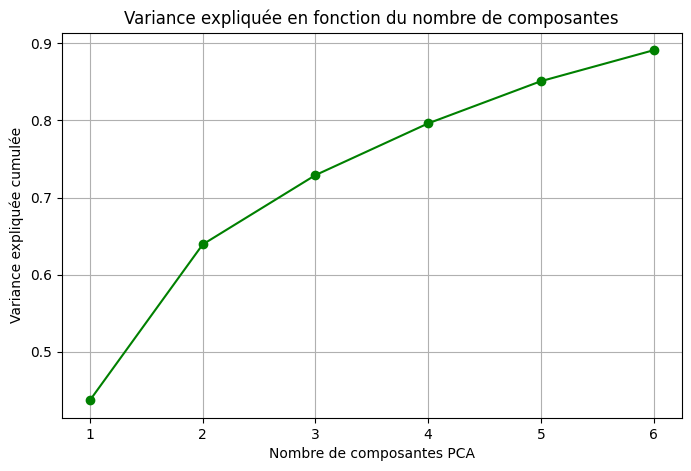

In [9]:
n_components_range = range(1, 7)
explained_variances = []

for n in n_components_range:
    pca = PCA(n_components=n)
    pca.fit(X_train_s)
    explained_variances.append(pca.explained_variance_ratio_.sum())

plt.figure(figsize=(8, 5))
plt.plot(list(n_components_range), explained_variances, 'go-')
plt.xlabel('Nombre de composantes PCA')
plt.ylabel('Variance expliquée cumulée')
plt.title('Variance expliquée en fonction du nombre de composantes')
plt.grid(True)
plt.xticks(list(n_components_range))
plt.show()

Dessinez une figure : axe x = nombre de composantes [1–6], axe y = score du modèle SVM sur les données de test

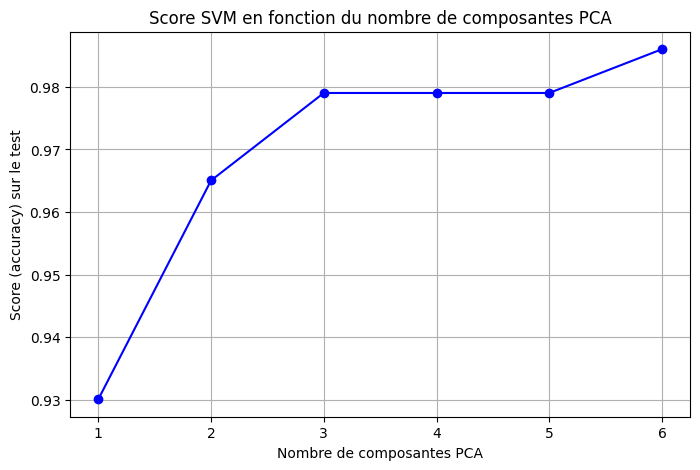

In [10]:
scores_pca = []

for n in n_components_range:
    pca = PCA(n_components=n)
    X_tr_pca = pca.fit_transform(X_train_s)
    X_te_pca = pca.transform(X_test_s)
    
    svm_tmp = SVC(random_state=42)
    svm_tmp.fit(X_tr_pca, y_train)
    scores_pca.append(accuracy_score(y_test, svm_tmp.predict(X_te_pca)))

plt.figure(figsize=(8, 5))
plt.plot(list(n_components_range), scores_pca, 'bo-')
plt.xlabel('Nombre de composantes PCA')
plt.ylabel('Score (accuracy) sur le test')
plt.title('Score SVM en fonction du nombre de composantes PCA')
plt.grid(True)
plt.xticks(list(n_components_range))
plt.show()

**Apprentissage non supervisé avec KMeans**

- Prétraitement avec `MinMaxScaler`
- Réduction à 2 dimensions avec PCA
- Clustering KMeans avec 2 clusters
- Afficher les données et les résultats du clustering sur la même figure

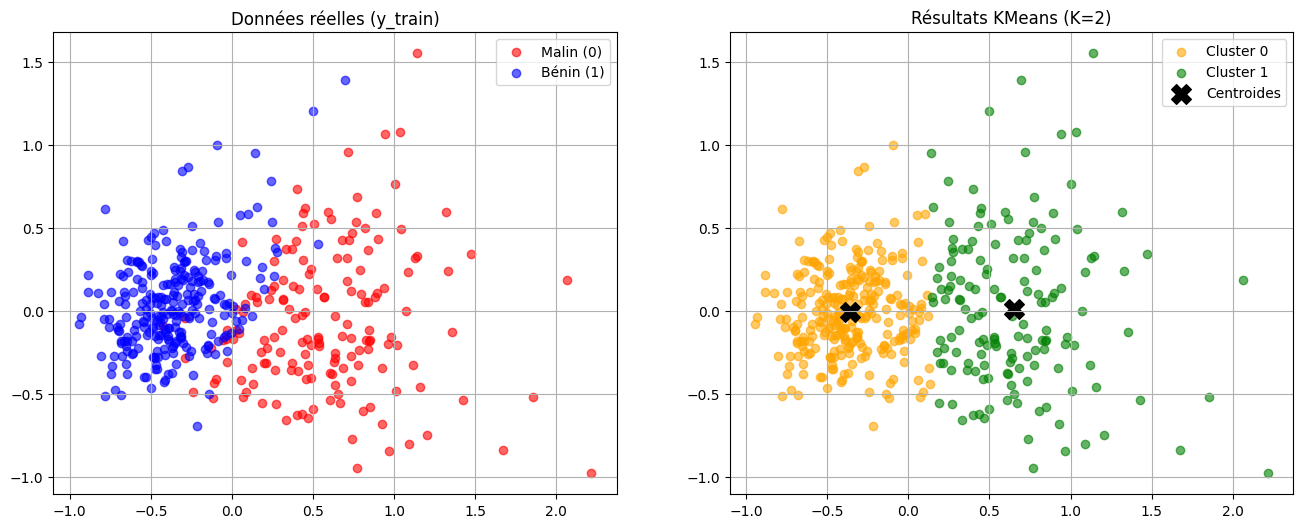

In [11]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

# Prétraitement MinMaxScaler
mms = MinMaxScaler()
X_train_mm = mms.fit_transform(X_train)
X_test_mm = mms.transform(X_test)

# Réduction PCA = 2
pca_mm = PCA(n_components=2)
X_train_pca_mm = pca_mm.fit_transform(X_train_mm)

# KMeans clustering
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X_train_pca_mm)

labels_km = kmeans.labels_
centers_km = kmeans.cluster_centers_

# Visualisation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Données réelles (y_train)
ax1.scatter(X_train_pca_mm[y_train == 0, 0], X_train_pca_mm[y_train == 0, 1],
            c='red', label='Malin (0)', alpha=0.6)
ax1.scatter(X_train_pca_mm[y_train == 1, 0], X_train_pca_mm[y_train == 1, 1],
            c='blue', label='Bénin (1)', alpha=0.6)
ax1.set_title('Données réelles (y_train)')
ax1.legend()
ax1.grid(True)

# Résultats du clustering
ax2.scatter(X_train_pca_mm[labels_km == 0, 0], X_train_pca_mm[labels_km == 0, 1],
            c='orange', label='Cluster 0', alpha=0.6)
ax2.scatter(X_train_pca_mm[labels_km == 1, 0], X_train_pca_mm[labels_km == 1, 1],
            c='green', label='Cluster 1', alpha=0.6)
ax2.scatter(centers_km[:, 0], centers_km[:, 1],
            c='black', marker='X', s=200, label='Centroides')
ax2.set_title('Résultats KMeans (K=2)')
ax2.legend()
ax2.grid(True)

plt.show()

**Distorsion** : quelle est la distorsion lorsque PCA=2, clusters=2 ?

In [12]:
distortion = kmeans.inertia_
print(f"Distorsion (inertia) pour PCA=2, K=2 : {distortion:.4f}")

Distorsion (inertia) pour PCA=2, K=2 : 88.7415


**Nombre de composantes optimal pour un score de 0.99 sur les données de test**

On peut passer un float à `PCA(n_components=...)` pour spécifier la variance expliquée minimale souhaitée.
PCA choisira alors automatiquement le nombre de composantes nécessaires.

In [13]:
# Méthode 1 : passer un float à PCA pour spécifier la variance expliquée minimale
pca_99 = PCA(n_components=0.99)  # conserve 99% de la variance
X_train_99 = pca_99.fit_transform(X_train_s)
X_test_99 = pca_99.transform(X_test_s)

print(f"Nombre de composantes pour 99% de variance : {pca_99.n_components_}")
print(f"Variance expliquée : {pca_99.explained_variance_ratio_.sum():.4f}")

# Score SVM avec ce nombre de composantes
svm_99 = SVC(random_state=42)
svm_99.fit(X_train_99, y_train)
score_99 = accuracy_score(y_test, svm_99.predict(X_test_99))
print(f"Score SVM avec PCA(0.99) : {score_99:.4f}")

# Méthode 2 : chercher le nombre de composantes qui donne score >= 0.99 sur le test
print("\nRecherche du nombre de composantes pour score >= 0.99 sur le test :")
for n in range(1, X_train_s.shape[1] + 1):
    pca_n = PCA(n_components=n)
    X_tr_n = pca_n.fit_transform(X_train_s)
    X_te_n = pca_n.transform(X_test_s)
    svm_n = SVC(random_state=42)
    svm_n.fit(X_tr_n, y_train)
    s = accuracy_score(y_test, svm_n.predict(X_te_n))
    print(f"  n_components={n} -> score={s:.4f}")
    if s >= 0.99:
        print(f"  => Premier n_components donnant score >= 0.99 : {n}")
        break

Nombre de composantes pour 99% de variance : 17
Variance expliquée : 0.9919
Score SVM avec PCA(0.99) : 0.9860

Recherche du nombre de composantes pour score >= 0.99 sur le test :
  n_components=1 -> score=0.9301
  n_components=2 -> score=0.9650
  n_components=3 -> score=0.9790
  n_components=4 -> score=0.9790
  n_components=5 -> score=0.9790
  n_components=6 -> score=0.9860
  n_components=7 -> score=0.9860
  n_components=8 -> score=0.9860
  n_components=9 -> score=0.9860
  n_components=10 -> score=0.9860
  n_components=11 -> score=0.9860
  n_components=12 -> score=0.9860
  n_components=13 -> score=0.9860
  n_components=14 -> score=0.9860
  n_components=15 -> score=0.9860
  n_components=16 -> score=0.9860
  n_components=17 -> score=0.9860
  n_components=18 -> score=0.9860
  n_components=19 -> score=0.9860
  n_components=20 -> score=0.9860
  n_components=21 -> score=0.9860
  n_components=22 -> score=0.9860
  n_components=23 -> score=0.9860
  n_components=24 -> score=0.9860
  n_components